## Aspect-Based Sentiment Analysis Comparison
### **Course:** Applied Computer Science – Data & AI 6
### **Team:** Vladalin Bosii, Aleksiya Solovyova
##### **Date:** 2025-10-13
This notebook compares three different ABSA implementations:
- **Lexicon-based (spaCy + VADER)**
- **Transformer-based (Pretrained ABSA model)**
- **LLM-based (Ollama local LLM)**

We run all three on a subset of the Yelp Reviews dataset (~1000 samples),
then compare performance, accuracy, and qualitative behavior.

In [1]:
import pandas as pd
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from typing import List, Dict, Any
import numpy as np
import matplotlib.pyplot as plt

from src.base import ABSAAnalyzer, AspectSentiment
from src.lexicon_absa import LexiconABSA
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA
from src.utils import load_test_samples, compare_analyzers

In [2]:
ds= load_test_samples('../data/test_samples.json')
print(f"Loaded {len(ds)} reviews.")
print(f"Example review:\n{ds[78]['text']}\nStars: {ds[78]['stars']}\n")


Loaded 100 reviews.
Example review:
Great little deli. Sandwiches are huge and packed with quality meats and cheeses. The pickles are house-made and delicious. Cash only but there's an ATM inside.
Stars: 4



In [3]:
lexicon_analyzer = LexiconABSA()
transformer_analyzer = TransformerABSA()
llm_analyzer = LLMABSA(model_name="orca2")

analyzers = {
    "Lexicon": lexicon_analyzer,
    "Transformer": transformer_analyzer,
    "LLM": llm_analyzer
}

Loading transformer model: yangheng/deberta-v3-base-absa-v1.1...


/home/aleks/PycharmProjects/data6team28/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Model 'yangheng/deberta-v3-base-absa-v1.1' loaded successfully.
Model 'orca2' ready


In [4]:
sample_texts = [s["text"] for s in ds[:3]]

for i, text in enumerate(sample_texts):
    print(f"\n Review {i+1}: {text[:100]}...\n")
    df = compare_analyzers(text, analyzers)
    display(df)


 Review 1: If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We...

JSON parse failed: Expecting ',' delimiter: line 5 column 75 (char 230)


,analyzer,aspect,sentiment,confidence
0,Lexicon,waitstaff,positive,0.665200
1,Lexicon,food,positive,0.400800
2,Transformer,hours,negative,0.984629
3,Transformer,end,negative,0.683177
4,Transformer,times,negative,0.932060
5,Transformer,food,positive,0.973733
6,Transformer,waitstaff,positive,0.517607
7,LLM,wait,positive,0.800000
8,LLM,food,positive,0.800000
9,LLM,staff,positive,0.800000



 Review 2: Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two ...



,analyzer,aspect,sentiment,confidence
0,Lexicon,meal,positive,0.348100
1,Lexicon,grape,positive,0.318200
2,Lexicon,expectation,positive,0.690800
3,Lexicon,tamale,positive,0.318200
4,Lexicon,leave,positive,0.318200
5,Lexicon,assortment,positive,0.318200
6,Lexicon,chicken,positive,0.318200
7,Lexicon,melon,positive,0.379300
8,Lexicon,jalapeño,positive,0.318200
9,Lexicon,leg,positive,0.318200



 Review 3: Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds ...



,analyzer,aspect,sentiment,confidence
0,Lexicon,favorite,positive,0.571900
1,Lexicon,curry,positive,0.458800
2,Lexicon,korma,positive,0.458800
3,Lexicon,lamb,positive,0.458800
4,Transformer,favorite,positive,0.990030
5,Transformer,lamb,positive,0.991294
6,Transformer,curry,positive,0.983332
7,Transformer,korma,positive,0.992422
8,Transformer,kinds,positive,0.984801
9,LLM,food,positive,0.900000


In [5]:
def normalize_sentiment(label: str) -> str:
    if not label:
        return 'neutral'
    l = label.lower().strip()
    if l.startswith('pos'):
        return 'positive'
    if l.startswith('neg'):
        return 'negative'
    return 'neutral'




def stars_to_label(stars: int) -> str:
    if stars >= 4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'




def aggregate_aspect_sentiments(aspects: List[AspectSentiment]) -> str:
    if not aspects:
        return 'neutral'
    mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
    scores = [mapping.get(normalize_sentiment(a.sentiment), 0) * (a.confidence or 1.0) for a in aspects]
    avg_score = np.mean(scores)
    if avg_score > 0.2:
        return 'positive'
    elif avg_score < -0.2:
        return 'negative'
    return 'neutral'




def evaluate_overall_sentiment(analyzer: ABSAAnalyzer, reviews: List[Dict[str, Any]]):
    y_true, y_pred, times, num_aspects, confs = [], [], [], [], []


    for review in reviews:
        text = review['text']
        gold_label = stars_to_label(review.get('stars', 3))


        t0 = time.perf_counter()
        try:
            preds = analyzer.analyze(text)
        except Exception as e:
            print('Error analyzing text:', e)
            preds = []
        t1 = time.perf_counter()

        pred_label = aggregate_aspect_sentiments(preds)
        y_true.append(gold_label)
        y_pred.append(pred_label)
        times.append(t1 - t0)
        num_aspects.append(len(preds))
        confs.append(np.mean([p.confidence for p in preds]) if preds else 0)


    metrics = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    summary = {
        'precision': metrics['weighted avg']['precision'],
        'recall': metrics['weighted avg']['recall'],
        'f1': metrics['weighted avg']['f1-score'],
        'accuracy': accuracy_score(y_true, y_pred),
        'avg_time_s': float(np.mean(times)),
        'avg_aspects': float(np.mean(num_aspects)),
        'avg_confidence': float(np.mean(confs))
    }
    return summary, metrics

In [6]:
def star_to_sentiment(stars):
    if stars >= 4:
        return "positive"
    elif stars == 3:
        return "neutral"
    else:
        return "negative"

def evaluate(predictions, dataset):
    gold = [star_to_sentiment(s["stars"]) for s in dataset]

    preds = []
    for aspects in predictions:
        if not aspects:
            preds.append("neutral")
            continue

        sentiments = []
        for a in aspects:
            if hasattr(a, "sentiment"):
                sentiments.append(a.sentiment)
            elif isinstance(a, dict) and "sentiment" in a:
                sentiments.append(a["sentiment"])

        score = sum(1 if s == "positive" else -1 if s == "negative" else 0 for s in sentiments)
        preds.append("positive" if score > 0 else "negative" if score < 0 else "neutral")

    acc = accuracy_score(gold, preds)
    p, r, f1, _ = precision_recall_fscore_support(gold, preds, average="macro")
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}


In [7]:
def aspect_sentiment_pairs(lst):
    return set((x['aspect'].lower().strip(), x['sentiment'].lower().strip()) for x in lst)

all_results = []
for d in ds:
    gold = aspect_sentiment_pairs(d.get("aspects", []))
    for name, analyzer in analyzers.items():
        pred = aspect_sentiment_pairs(
            [{"aspect": a.aspect, "sentiment": a.sentiment} for a in analyzer.analyze(d["text"])]
        )
        tp = len(gold & pred)
        fp = len(pred - gold)
        fn = len(gold - pred)
        all_results.append({
            "model": name,
            "tp": tp,
            "fp": fp,
            "fn": fn
        })
df_eval = pd.DataFrame(all_results).groupby("model").sum()
df_eval["precision"] = df_eval["tp"] / (df_eval["tp"] + df_eval["fp"] + 1e-8)
df_eval["recall"] = df_eval["tp"] / (df_eval["tp"] + df_eval["fn"] + 1e-8)
df_eval["f1"] = 2 * df_eval["precision"] * df_eval["recall"] / (df_eval["precision"] + df_eval["recall"] + 1e-8)
display(df_eval)

JSON parse failed: Expecting ',' delimiter: line 5 column 75 (char 230)
JSON parse failed: Expecting ',' delimiter: line 9 column 4 (char 183)
JSON parse failed: Expecting ',' delimiter: line 5 column 68 (char 227)


KeyboardInterrupt: 

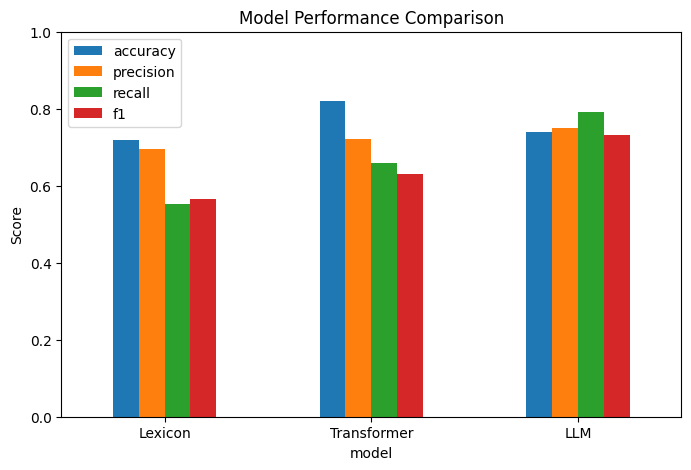

,model,accuracy,precision,recall,f1,avg_time_per_review
2,LLM,0.74,0.750794,0.790586,0.731857,32.606760
1,Transformer,0.82,0.721290,0.659105,0.630252,0.580819
0,Lexicon,0.72,0.694515,0.552778,0.566053,0.017883


In [7]:
results_summary = {}
results_detailed = {}

for name, analyzer in analyzers.items():
    print(f'\nEvaluating {name}...')
    summary, metrics = evaluate_overall_sentiment(analyzer, ds)
    results_summary[name] = summary
    results_detailed[name] = metrics
    print(pd.DataFrame([summary]))

results_df = pd.DataFrame(results_summary).T
print('\n--- Overall Comparison ---')
display(results_df)

In [9]:
sample_rows = []
for item in ds[:10]:
    text = item['text']
    row = {'text': text[:200] + ('...' if len(text) > 200 else ''), 'stars': item['stars']}
    for name, analyzer in analyzers.items():
        try:
            preds = analyzer.analyze(text)
            row[name] = [p.to_dict() for p in preds]
        except Exception as e:
            row[name] = f'Error: {e}'
    sample_rows.append(row)

display(pd.DataFrame(sample_rows))

📝 Review: Great little deli. Sandwiches are huge and packed with quality meats and cheeses. The pickles are house-made and delicious. Cash only but there's an ATM inside.

Model: Lexicon
   Aspect('pickle') → Sentiment: POSITIVE (conf: 0.57)
   Aspect('cheese') → Sentiment: POSITIVE (conf: 0.32)
   Aspect('quality') → Sentiment: POSITIVE (conf: 0.32)
   Aspect('cash') → Sentiment: POSITIVE (conf: 0.57)
   Aspect('deli') → Sentiment: POSITIVE (conf: 0.62)
   Aspect('meat') → Sentiment: POSITIVE (conf: 0.32)
   Aspect('sandwich') → Sentiment: POSITIVE (conf: 0.32)

Model: Transformer
   Aspect('deli') → Sentiment: POSITIVE (conf: 0.99)
   Aspect('sandwiches') → Sentiment: POSITIVE (conf: 0.99)
   Aspect('quality') → Sentiment: POSITIVE (conf: 0.93)
   Aspect('meats') → Sentiment: POSITIVE (conf: 1.00)
   Aspect('cheeses') → Sentiment: POSITIVE (conf: 0.98)

Model: LLM
⏱️ Slow analysis (22.8s): 'Great little deli. Sandwiches are huge and packed ...'
   Aspect('food') → Sentiment: POSITIVE